# Marathon Data Analysis
Refactored analysis with DRY principles applied

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FIGURE_SIZE = (8, 5)
ALPHA_DEFAULT = 0.5
SCATTER_ALPHA = 0.2
SCATTER_SIZE = 3
MARATHON_DISTANCE = 42.195

In [79]:
def time_to_minutes(t):
    if len(t) == 8:
        h, m, s = map(int, t.split(":"))
        return h*60 + m + s/60
    elif len(t) == 5:
        m, s = map(int, t.split(":"))
        return m + s/60

def plot_gender_histogram(data, col, title, xlabel, **kwargs):
    plt.figure(figsize=FIGURE_SIZE)
    men_data = data[data["gender"] == "M"][col]
    women_data = data[data["gender"] == "W"][col]
    
    plt.hist(men_data, bins=30, alpha=ALPHA_DEFAULT, edgecolor="black", label="Men")
    plt.hist(women_data, bins=30, alpha=ALPHA_DEFAULT, edgecolor="black", label="Women")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Number of runners")
    plt.legend()
    plt.show()

def plot_scatter(x_data, y_data, title, xlabel, ylabel, **kwargs):
    plt.figure(figsize=FIGURE_SIZE)
    plt.scatter(x_data, y_data, s=5, alpha=SCATTER_ALPHA, color="purple", **kwargs)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

def plot_boxplot(data_dict, title, ylabel):
    plt.figure(figsize=FIGURE_SIZE)
    plt.boxplot(list(data_dict.values()), tick_labels=list(data_dict.keys()))
    plt.title(title)
    plt.ylabel(ylabel)
    plt.show()

In [80]:
df = pd.read_csv("marathon-data.csv")

print(df.head())
print(df.columns)
print(df.dtypes)
print(df.isna().sum())

   age gender     split     final
0   33      M  01:05:38  02:08:51
1   32      M  01:06:26  02:09:28
2   31      M  01:06:49  02:10:42
3   38      M  01:06:16  02:13:45
4   31      M  01:06:32  02:13:59
Index(['age', 'gender', 'split', 'final'], dtype='object')
age        int64
gender    object
split     object
final     object
dtype: object
age       0
gender    0
split     0
final     0
dtype: int64


In [81]:
df["final_minutes"] = df["final"].apply(time_to_minutes)
df["split_minutes"] = df["split"].apply(time_to_minutes)
df["pace"] = df["final_minutes"] / MARATHON_DISTANCE
df["second_half_time"] = df["final_minutes"] - df["split_minutes"]
df["time_score"] = df["second_half_time"] / df["split_minutes"]

print(df[["final_minutes", "split_minutes", "pace"]].head())

   final_minutes  split_minutes      pace
0     128.850000      65.633333  3.053679
1     129.466667      66.433333  3.068294
2     130.700000      66.816667  3.097523
3     133.750000      66.266667  3.169807
4     133.983333      66.533333  3.175337


In [82]:
print(f"Gender values: {df['gender'].unique()}")
print(f"Age range: {df['age'].min()} - {df['age'].max()}")

Gender values: ['M' 'W']
Age range: 17 - 86


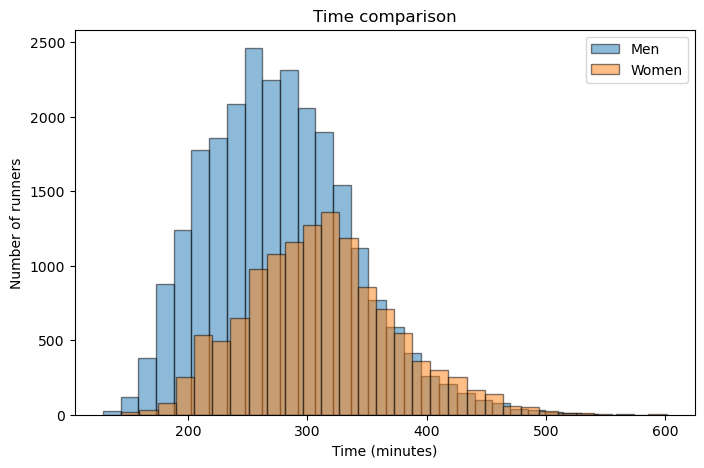

In [83]:
plot_gender_histogram(df, "final_minutes", "Time comparison", "Time (minutes)")

In [84]:
gender_stats = df.groupby("gender")["final_minutes"].agg(['mean', 'median', 'std'])
print("Finish time statistics by gender:")
print(gender_stats)

Finish time statistics by gender:
              mean      median        std
gender                                   
M       276.477331  272.550000  60.956342
W       311.041924  308.733333  62.252287


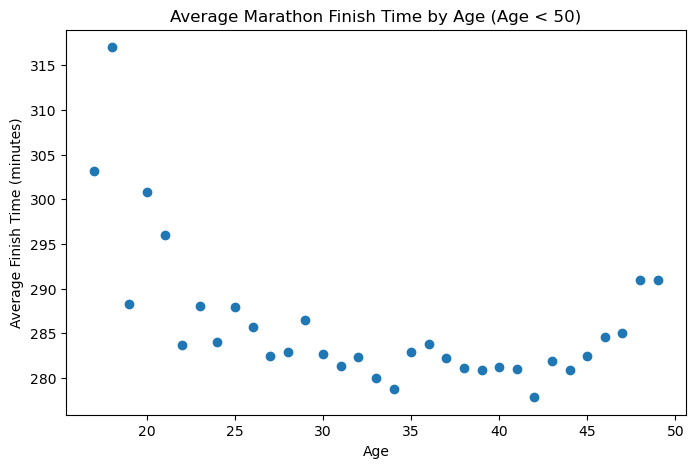

In [85]:
age_pace = df[df["age"] < 50].groupby("age")["final_minutes"].mean()

plt.figure(figsize=FIGURE_SIZE)
plt.scatter(age_pace.index, age_pace.values)
plt.title("Average Marathon Finish Time by Age (Age < 50)")
plt.xlabel("Age")
plt.ylabel("Average Finish Time (minutes)")
plt.show()

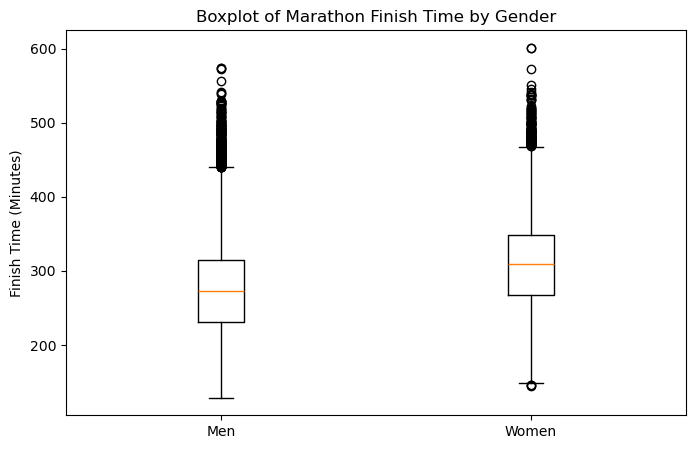

In [86]:
men = df[df["gender"] == "M"]["final_minutes"]
women = df[df["gender"] == "W"]["final_minutes"]

plot_boxplot({"Men": men, "Women": women}, "Boxplot of Marathon Finish Time by Gender", "Finish Time (Minutes)")

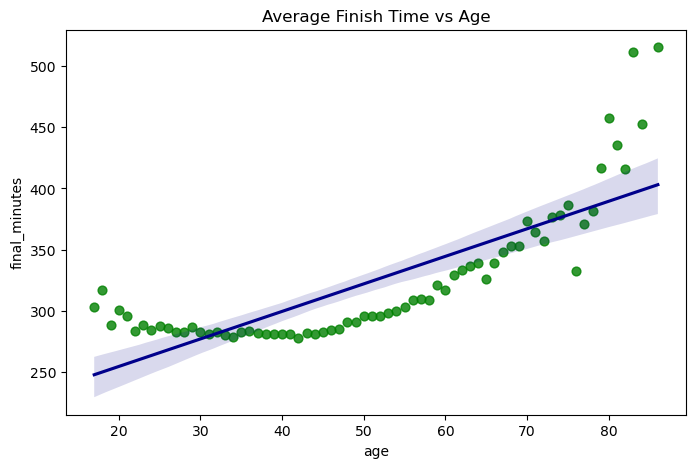

In [87]:
age_pace = df.groupby("age")["final_minutes"].mean().reset_index()

plt.figure(figsize=FIGURE_SIZE)
sns.regplot(data=age_pace, x="age", y="final_minutes", 
            scatter_kws={"color": "green", "s": 40},
            line_kws={"color": "darkblue"})
plt.title("Average Finish Time vs Age")
plt.show()

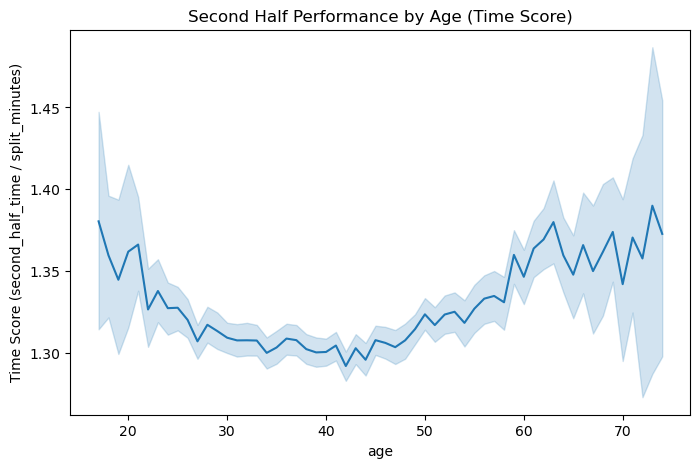

In [88]:
plt.figure(figsize=FIGURE_SIZE)
sns.lineplot(data=df[df["age"] < 75], x="age", y="time_score")
plt.title("Second Half Performance by Age (Time Score)")
plt.ylabel("Time Score (second_half_time / split_minutes)")
plt.show()

In [89]:
import numpy as np

men_times = df[df["gender"] == "M"]["final_minutes"]
women_times = df[df["gender"] == "W"]["final_minutes"]

percentiles = [25, 50, 75, 90, 95]

for p in percentiles:
    print(f"Percentile {p} for men = {np.percentile(men_times, p)}")
    print(f"Percentile {p} for women = {np.percentile(women_times, p)}")

q1 = np.percentile(men_times, 25)
q3 = np.percentile(men_times, 75)

iqr = q3 - q1
print(f"IQR (men) = {iqr}")

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Lower outlier threshold: {lower_bound}")
print(f"Upper outlier threshold: {upper_bound}")

outliers_men = men_times[(men_times < lower_bound) | (men_times > upper_bound)]
print(outliers_men)

Percentile 25 for men = 231.76666666666668
Percentile 25 for women = 267.6
Percentile 50 for men = 272.55
Percentile 50 for women = 308.73333333333335
Percentile 75 for men = 314.9166666666667
Percentile 75 for women = 347.8666666666667
Percentile 90 for men = 355.28333333333336
Percentile 90 for women = 392.74666666666667
Percentile 95 for men = 383.18333333333334
Percentile 95 for women = 424.24666666666667
IQR (men) = 83.15
Lower outlier threshold: 107.04166666666667
Upper outlier threshold: 439.6416666666667
36565    439.900000
36566    439.916667
36569    439.983333
36570    440.083333
36571    440.133333
            ...    
37240    541.516667
37243    556.250000
37245    572.950000
37246    573.466667
37247    573.666667
Name: final_minutes, Length: 296, dtype: float64


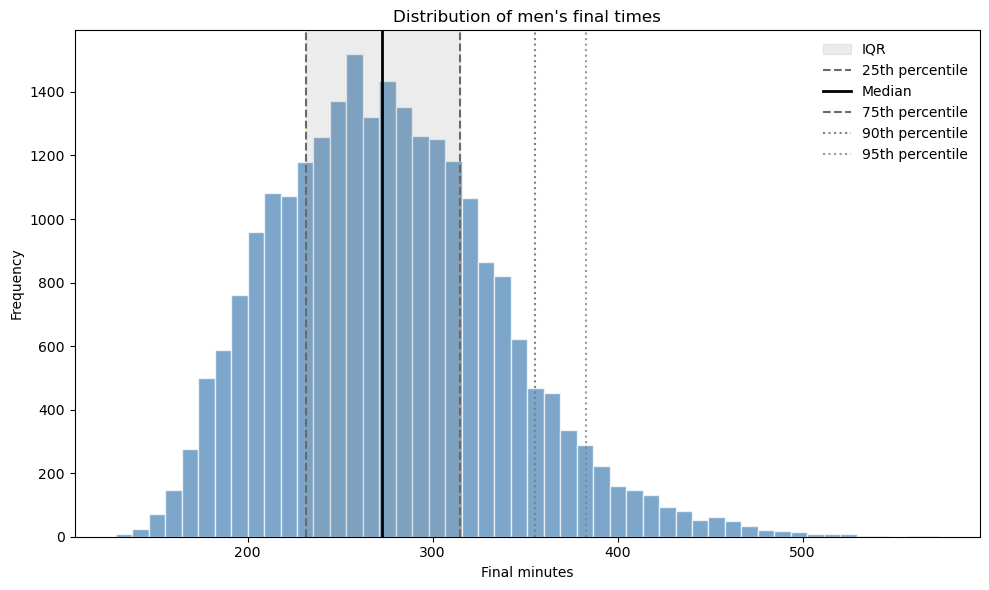

In [90]:
plt.figure(figsize=(10, 6))
plt.hist(men_times, bins=50, alpha=0.7, color="steelblue", edgecolor="white")

q1 = np.percentile(men_times, 25)
q2 = np.percentile(men_times, 50)
q3 = np.percentile(men_times, 75)
p90 = np.percentile(men_times, 90)
p95 = np.percentile(men_times, 95)


plt.axvspan(q1, q3, alpha=0.15, color="gray", label="IQR")


plt.axvline(q1, color="dimgray", linestyle="--", linewidth=1.5, label="25th percentile")
plt.axvline(q2, color="black", linestyle="-", linewidth=2, label="Median")
plt.axvline(q3, color="dimgray", linestyle="--", linewidth=1.5, label="75th percentile")

plt.axvline(p90, color="gray", linestyle=":", linewidth=1.5, label="90th percentile")
plt.axvline(p95, color="gray", linestyle=":", linewidth=1.5, alpha=0.8, label="95th percentile")

plt.title("Distribution of men's final times")
plt.xlabel("Final minutes")
plt.ylabel("Frequency")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

<Axes: >

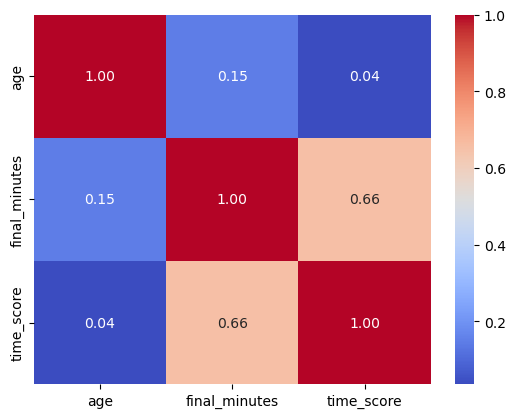

In [91]:
corr = df.drop(columns=["pace", "split_minutes", "second_half_time"]).corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

In [92]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
def encode_gender(gender):
    if gender == "M":
        return 1
    return 0

df["gender"] = df["gender"].apply(encode_gender)

X = df[["age", "gender", "split_minutes"]]
y = df["final_minutes"]

print(X.dtypes)
print(y.dtypes)

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


print(f"R2: {r2_score(y_test, y_pred)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")


print(f"Train R2: {model.score(X_train, y_train)}")
print(f"Test R2: {model.score(X_test, y_test)}")

print(f"model coef: {model.coef_}")
print(f"model intercept: {model.intercept_}")

# from coefs --> final ≈ 2.65 × split, it shows well that second half is slower

age                int64
gender             int64
split_minutes    float64
dtype: object
float64
R2: 0.9160026767450085
MAE: 14.211485572185508
MSE: 345.4656501920394
RMSE: 18.58670627604685
Train R2: 0.9132365303966071
Test R2: 0.9160026767450085
model coef: [-0.10049159  3.51049367  2.67382795]
model intercept: -41.40026269193527


In [93]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForest": RandomForestRegressor(random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name, "R2:", r2_score(y_test, y_pred))

print("Lasso coef:", models["Lasso"].coef_)

Ridge R2: 0.9160026926266721
Lasso R2: 0.9155009428226563
RandomForest R2: 0.9093162167730586
Lasso coef: [-0.0545632   0.          2.64728969]


In [94]:
pivot = pd.pivot_table(df, index="age", columns="gender", values="final_minutes", fill_value=0, aggfunc="mean")

pivot.reset_index().rename(columns= {0: "women", 1: "men"}).head(10).style.format({"women": "{:.2f}", "men": "{:.2f}"}).hide(axis="index")




age,women,men
17,307.10,301.08
18,330.09,309.19
19,307.15,280.13
20,316.52,294.68
21,330.54,276.84
22,302.81,268.43
23,298.77,278.54
24,299.62,268.75
25,304.29,267.51
26,300.46,270.98


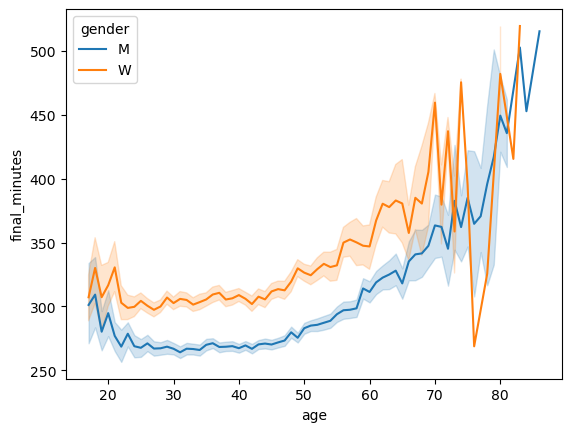

In [102]:
df["gender"] = df["gender"].map({0: "W", 1: "M"})
plot = sns.lineplot(data=df, x="age", y="final_minutes", hue="gender", markers=True)

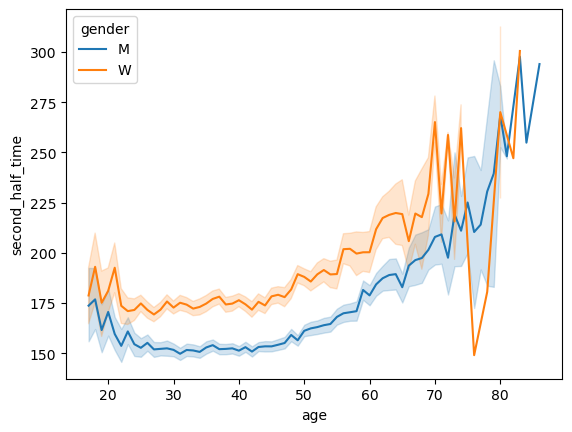

In [103]:
plot = sns.lineplot(data=df, x="age", y="second_half_time", hue="gender", markers=True)

## Conclusions

The analysis shows that split time is the strongest predictor of final marathon time.

Runners who are faster in the first half usually also finish faster overall. The regression model confirms this with a very high score.

Age and gender have some impact on finish time, but their influence is much smaller than split time.

The second half of the marathon is usually slower than the first half, which suggests that many runners lose pace later in the race.

Overall, the model works well for predicting final marathon time, mainly because split time already contains a lot of information about runner performance.